In [1]:
import os
import time
import json
import hashlib
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for cand in (p, *p.parents):
        if (cand / '.git').exists() and (cand / 'Voxelmorph').exists():
            return cand
    raise RuntimeError(f'Could not locate repository root from {start}')


def _resolve_file(path_str: str) -> str:
    p = Path(path_str)
    if p.exists():
        return str(p)
    for rel in ('./data/test_data', './test_data'):
        alt = Path(rel) / p.name
        if alt.exists():
            return str(alt)
    return str(p)


REPO_ROOT = _find_repo_root(Path.cwd())

MODEL_PATH = str((REPO_ROOT / 'Voxelmorph/trained_weights/2p5d_dense_pt_best.pth').resolve())
XMODEL_PATH = str((REPO_ROOT / 'out/v2.5/vxm_2p5d_pt_v3/compiled/vxm_2p5d_pt_v3.xmodel').resolve())
MR_VOLUME_PATH = str((REPO_ROOT / 'Voxelmorph/2.5D/data/test_data/1BA001_mr.npy').resolve())
CT_VOLUME_PATH = str((REPO_ROOT / 'Voxelmorph/2.5D/data/test_data/1BA005_ct.npy').resolve())
MR_SEG_PATH = str((REPO_ROOT / 'Voxelmorph/2.5D/data/test_data/1BA001_mr_seg.npy').resolve())
CT_SEG_PATH = str((REPO_ROOT / 'Voxelmorph/2.5D/data/test_data/1BA005_ct_seg.npy').resolve())

INPUT_HEIGHT, INPUT_WIDTH = 112, 96
WINDOW_RADIUS = 3
N_STACK = 8
SEG_LABELS = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]

OUTPUT_DIR = './gpu_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

QUIVER_AUTO_GAIN = True
QUIVER_TARGET_P95 = 2.0
QUIVER_MAX_GAIN = 20.0
QUIVER_DISPLAY_FLIP_Y = True

MODEL_PATH = _resolve_file(MODEL_PATH)
XMODEL_PATH = _resolve_file(XMODEL_PATH)
MR_VOLUME_PATH = _resolve_file(MR_VOLUME_PATH)
CT_VOLUME_PATH = _resolve_file(CT_VOLUME_PATH)
MR_SEG_PATH = _resolve_file(MR_SEG_PATH)
CT_SEG_PATH = _resolve_file(CT_SEG_PATH)

print('Configuration:')
print(f'  Device: {device}')
print(f'  Model weights: {MODEL_PATH}')
print(f'  Reference xmodel: {XMODEL_PATH}')
print('  Test data: CROSS-SUBJECT (1BA001 MR -> 1BA005 CT)')
print(f'  Input size: {INPUT_HEIGHT}x{INPUT_WIDTH}')
print(f'  Stack size: {N_STACK} slices')
print('  Path: PyTorch GPU float inference')
print(f"  Quiver display: auto_gain={QUIVER_AUTO_GAIN}, target_p95={QUIVER_TARGET_P95}, max_gain={QUIVER_MAX_GAIN}, flip_y={QUIVER_DISPLAY_FLIP_Y}")


In [3]:
class Vxm2p5dDenseCore(nn.Module):
    def __init__(self, n_stack=8, enc_feats=(16, 32, 32, 32), final_feats=(32, 16), flow_scale=0.1):
        super().__init__()
        self.enc_blocks = nn.ModuleList()
        self.down_blocks = nn.ModuleList()
        in_ch = n_stack * 2

        for nf in enc_feats:
            self.enc_blocks.append(nn.Sequential(
                nn.Conv2d(in_ch, nf, 3, padding=1, bias=False),
                nn.BatchNorm2d(nf),
                nn.LeakyReLU(0.1),
            ))
            self.down_blocks.append(nn.Sequential(
                nn.Conv2d(nf, nf, 3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(nf),
                nn.LeakyReLU(0.1),
            ))
            in_ch = nf

        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
        )

        self.up_blocks = nn.ModuleList()
        self.dec_blocks = nn.ModuleList()

        in_ch = 32
        for skip_ch in reversed(enc_feats):
            self.up_blocks.append(nn.Upsample(scale_factor=2, mode='nearest'))
            self.dec_blocks.append(nn.Sequential(
                nn.Conv2d(in_ch + skip_ch, skip_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(skip_ch),
                nn.LeakyReLU(0.1),
            ))
            in_ch = skip_ch

        self.final_conv0 = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
        )
        self.final_conv1 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
        )

        self.flow_unscaled = nn.Conv2d(16, 2, 3, padding=1)
        nn.init.zeros_(self.flow_unscaled.weight)
        nn.init.zeros_(self.flow_unscaled.bias)

        self.flow_scale = nn.Conv2d(2, 2, 1, bias=False)
        self.flow_scale.weight.data.zero_()
        self.flow_scale.weight.data[0, 0, 0, 0] = flow_scale
        self.flow_scale.weight.data[1, 1, 0, 0] = flow_scale
        self.flow_scale.weight.requires_grad = False

    def forward(self, moving, fixed):
        x = torch.cat([moving, fixed], dim=1)
        skips = []

        for enc, ds in zip(self.enc_blocks, self.down_blocks):
            x = enc(x)
            skips.append(x)
            x = ds(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.up_blocks, self.dec_blocks, reversed(skips)):
            x = up(x)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        x = self.final_conv0(x)
        x = self.final_conv1(x)

        flow = self.flow_unscaled(x)
        flow_scaled = self.flow_scale(flow)
        return flow_scaled


def _load_weights_strict(model: torch.nn.Module, weights_path: str, device: torch.device) -> None:
    state = torch.load(weights_path, map_location=device)
    if isinstance(state, dict) and 'state_dict' in state:
        state = state['state_dict']

    # Migration path: old checkpoints may have first conv in_channels=14, model expects 16.
    if isinstance(state, dict) and 'enc_blocks.0.0.weight' in state:
        ckpt_w = state['enc_blocks.0.0.weight']
        model_w = model.enc_blocks[0][0].weight
        if ckpt_w.shape[1] == 14 and model_w.shape[1] == 16:
            new_w = torch.zeros_like(model_w)
            new_w[:, :14, :, :] = ckpt_w
            state['enc_blocks.0.0.weight'] = new_w

    model.load_state_dict(state, strict=True)


model = Vxm2p5dDenseCore(n_stack=N_STACK).to(device)
_load_weights_strict(model, MODEL_PATH, device)
model.eval()
print('Model loaded in strict mode.')


Model loaded in strict mode.


In [4]:
def extract_slice_stack(volume, axis, z, window_radius, target_size=(112, 96)):
    wr = window_radius
    if axis == 0:
        stack = volume[z-wr:z+wr+1]
    elif axis == 1:
        stack = volume[:, z-wr:z+wr+1, :].transpose(1, 0, 2)
    else:
        stack = volume[:, :, z-wr:z+wr+1].transpose(2, 0, 1)

    resized_stack = []
    for i in range(stack.shape[0]):
        resized = cv2.resize(stack[i], (target_size[1], target_size[0]), interpolation=cv2.INTER_LINEAR)
        resized_stack.append(resized)

    return np.ascontiguousarray(np.array(resized_stack))


def pad_stack_to_n(stack, n_stack):
    if stack.shape[0] == n_stack:
        return stack
    if stack.shape[0] > n_stack:
        return stack[:n_stack]
    out = stack.copy()
    while out.shape[0] < n_stack:
        out = np.concatenate([out, out[-1:]], axis=0)
    return out


def apply_flow_2d(image, flow):
    h, w = image.shape

    if flow.shape[1] != h or flow.shape[2] != w:
        flow_x = cv2.resize(flow[0], (w, h), interpolation=cv2.INTER_LINEAR)
        flow_y = cv2.resize(flow[1], (w, h), interpolation=cv2.INTER_LINEAR)
        scale_x = w / flow.shape[2]
        scale_y = h / flow.shape[1]
        flow_x = flow_x * scale_x
        flow_y = flow_y * scale_y
    else:
        flow_x = flow[0]
        flow_y = flow[1]

    y_coords, x_coords = np.mgrid[0:h, 0:w].astype(np.float32)
    new_x = x_coords + flow_x
    new_y = y_coords + flow_y
    warped = cv2.remap(image.astype(np.float32), new_x, new_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    return warped


def apply_flow_2d_nearest(image, flow):
    h, w = image.shape

    if flow.shape[1] != h or flow.shape[2] != w:
        flow_x = cv2.resize(flow[0], (w, h), interpolation=cv2.INTER_LINEAR)
        flow_y = cv2.resize(flow[1], (w, h), interpolation=cv2.INTER_LINEAR)
        scale_x = w / flow.shape[2]
        scale_y = h / flow.shape[1]
        flow_x = flow_x * scale_x
        flow_y = flow_y * scale_y
    else:
        flow_x = flow[0]
        flow_y = flow[1]

    y_coords, x_coords = np.mgrid[0:h, 0:w].astype(np.float32)
    new_x = x_coords + flow_x
    new_y = y_coords + flow_y
    warped = cv2.remap(image.astype(np.float32), new_x, new_y, cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT)
    return warped.astype(np.float32)


def _quiver_vis_gain(flow, target_p95=2.0, max_gain=20.0):
    mag = np.sqrt((flow[0] ** 2) + (flow[1] ** 2))
    p95 = float(np.percentile(mag, 95))
    if p95 <= 1e-8:
        return 1.0, p95
    gain = float(np.clip(target_p95 / p95, 1.0, max_gain))
    return gain, p95


def plot_quiver(ax, flow, background=None, step=4, auto_gain=True, target_p95=2.0, max_gain=20.0, display_flip_y=False):
    h, w = flow.shape[1], flow.shape[2]
    gain = 1.0
    p95 = 0.0
    if auto_gain:
        gain, p95 = _quiver_vis_gain(flow, target_p95=target_p95, max_gain=max_gain)

    y, x = np.mgrid[0:h:step, 0:w:step]
    fx = flow[0, ::step, ::step] * gain
    fy = flow[1, ::step, ::step] * gain
    if display_flip_y:
        fy = -fy
    bg = np.asarray(background) if background is not None else np.zeros((h, w), dtype=np.float32)
    ax.imshow(bg, cmap='gray', origin='upper')
    ax.quiver(x, y, fx, fy, color='red', angles='xy', scale_units='xy', scale=1, headwidth=3, headlength=4, alpha=0.8)
    ax.set_xlim(0, w - 1)
    ax.set_ylim(h - 1, 0)
    return gain, p95


def compute_dice(pred_seg, gt_seg, labels=SEG_LABELS):
    dice_scores = []
    for lbl in labels:
        pred_mask = (pred_seg == lbl).astype(np.float32)
        gt_mask = (gt_seg == lbl).astype(np.float32)
        gt_sum = gt_mask.sum()
        if gt_sum == 0:
            continue
        intersection = (pred_mask * gt_mask).sum()
        union = pred_mask.sum() + gt_sum
        dice_scores.append((2.0 * intersection + 1e-5) / (union + 1e-5))
    return float(np.mean(dice_scores)) if dice_scores else 0.0


def run_gpu_inference(moving_stack, fixed_stack):
    moving_stack = pad_stack_to_n(moving_stack, N_STACK)
    fixed_stack = pad_stack_to_n(fixed_stack, N_STACK)

    moving_input = torch.from_numpy(moving_stack[np.newaxis, ...].astype(np.float32)).to(device)
    fixed_input = torch.from_numpy(fixed_stack[np.newaxis, ...].astype(np.float32)).to(device)

    start = time.time()
    with torch.no_grad():
        flow_t = model(moving_input, fixed_input)
    duration = time.time() - start

    flow = flow_t.squeeze(0).detach().cpu().numpy().astype(np.float32)
    return flow, duration


In [5]:
moving_vol = np.load(MR_VOLUME_PATH).astype(np.float32)
fixed_vol = np.load(CT_VOLUME_PATH).astype(np.float32)

try:
    moving_seg = np.load(MR_SEG_PATH).astype(np.float32)
    fixed_seg = np.load(CT_SEG_PATH).astype(np.float32)
    has_seg = True
except Exception:
    has_seg = False
    moving_seg = np.zeros_like(moving_vol)
    fixed_seg = np.zeros_like(fixed_vol)
    print('Segmentation maps not found, skipping Dice evaluation.')

print(f'Moving: {moving_vol.shape}, range [{moving_vol.min():.3f}, {moving_vol.max():.3f}]')
print(f'Fixed: {fixed_vol.shape}, range [{fixed_vol.min():.3f}, {fixed_vol.max():.3f}]')
if has_seg:
    print(f'Moving Seg: {moving_seg.shape}, labels: {np.unique(moving_seg)}')
    print(f'Fixed Seg: {fixed_seg.shape}, labels: {np.unique(fixed_seg)}')


Moving: (176, 208, 192), range [-1.000, 1.000]
Fixed: (176, 208, 192), range [-1.000, 1.000]
Moving Seg: (176, 208, 192), labels: [ 0.  2.  3.  4.  5.  7.  8. 10. 11. 12. 13. 14. 15. 16. 17. 18. 24. 26.
 28.]
Fixed Seg: (176, 208, 192), labels: [ 0.  2.  3.  4.  5.  7.  8. 10. 11. 12. 13. 14. 15. 16. 17. 18. 24. 26.
 28.]



INFERENCE VERIFICATION
Inference time: 356.07 ms
Flow shape: (2, 112, 96)
Flow range: [-9.0833, 8.3275]
Flow mean: -0.7638, std: 2.3630



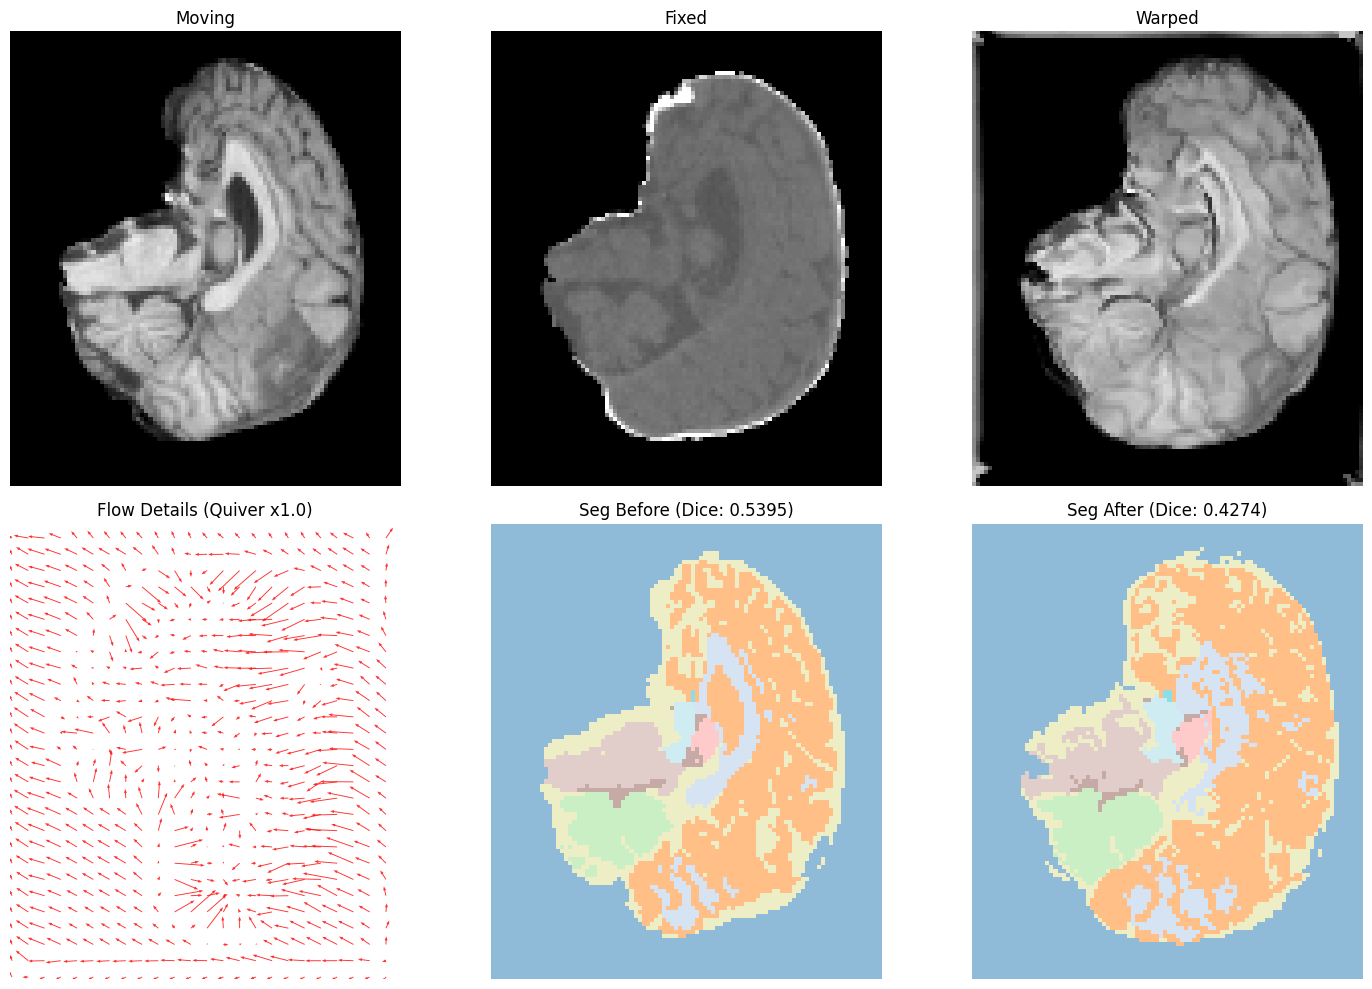

In [6]:
z_center = moving_vol.shape[0] // 2
moving_stack = extract_slice_stack(moving_vol, 0, z_center, WINDOW_RADIUS, (INPUT_HEIGHT, INPUT_WIDTH))
fixed_stack = extract_slice_stack(fixed_vol, 0, z_center, WINDOW_RADIUS, (INPUT_HEIGHT, INPUT_WIDTH))
if has_seg:
    moving_seg_center_full = moving_seg[z_center]
    fixed_seg_center_full = fixed_seg[z_center]
    moving_seg_center = cv2.resize(moving_seg_center_full, (INPUT_WIDTH, INPUT_HEIGHT), interpolation=cv2.INTER_NEAREST).astype(np.int16)
    fixed_seg_center = cv2.resize(fixed_seg_center_full, (INPUT_WIDTH, INPUT_HEIGHT), interpolation=cv2.INTER_NEAREST).astype(np.int16)
else:
    moving_seg_center_full = None
    fixed_seg_center_full = None
    moving_seg_center = None
    fixed_seg_center = None

flow, inf_time = run_gpu_inference(moving_stack, fixed_stack)

print('\n' + '='*70)
print('INFERENCE VERIFICATION')
print('='*70)
print(f'Inference time: {inf_time*1000:.2f} ms')
print(f'Flow shape: {flow.shape}')
print(f'Flow range: [{flow.min():.4f}, {flow.max():.4f}]')
print(f'Flow mean: {flow.mean():.4f}, std: {flow.std():.4f}')
print('='*70 + '\n')

center_idx = WINDOW_RADIUS
moving_center = moving_stack[center_idx]
fixed_center = fixed_stack[center_idx]
warped = apply_flow_2d(moving_center, flow)

if has_seg:
    warped_seg = apply_flow_2d_nearest(moving_seg_center, flow).astype(np.int16)
    dice_before = compute_dice(moving_seg_center, fixed_seg_center)
    dice_after = compute_dice(warped_seg, fixed_seg_center)
else:
    warped_seg = np.zeros_like(moving_center)
    dice_before = 0.0
    dice_after = 0.0

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(moving_center, cmap='gray')
axes[0, 0].set_title('Moving')
axes[0, 0].axis('off')

axes[0, 1].imshow(fixed_center, cmap='gray')
axes[0, 1].set_title('Fixed')
axes[0, 1].axis('off')

axes[0, 2].imshow(warped, cmap='gray')
axes[0, 2].set_title('Warped')
axes[0, 2].axis('off')

q_gain, q_p95 = plot_quiver(axes[1, 0], flow, background=moving_center, step=4, auto_gain=QUIVER_AUTO_GAIN, target_p95=QUIVER_TARGET_P95, max_gain=QUIVER_MAX_GAIN, display_flip_y=QUIVER_DISPLAY_FLIP_Y)
axes[1, 0].set_title(f'Flow Details (Quiver x{q_gain:.1f}, flip_y={QUIVER_DISPLAY_FLIP_Y})')
axes[1, 0].axis('off')

if has_seg:
    axes[1, 1].imshow(moving_seg_center, cmap='tab20', alpha=0.5)
    axes[1, 1].set_title(f'Seg Before (Dice: {dice_before:.4f})')
else:
    diff_before = np.abs(moving_center - fixed_center)
    axes[1, 1].imshow(diff_before, cmap='hot')
    axes[1, 1].set_title(f'Diff Before (MAE: {diff_before.mean():.4f})')
axes[1, 1].axis('off')

if has_seg:
    axes[1, 2].imshow(warped_seg, cmap='tab20', alpha=0.5)
    axes[1, 2].set_title(f'Seg After (Dice: {dice_after:.4f})')
else:
    diff_after = np.abs(warped - fixed_center)
    axes[1, 2].imshow(diff_after, cmap='hot')
    axes[1, 2].set_title(f'Diff After (MAE: {diff_after.mean():.4f})')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/single_slice.png', dpi=150)
plt.show()


In [7]:
def infer_full_volume(moving_vol, fixed_vol, moving_seg=None, axis=0):
    wr = WINDOW_RADIUS
    shape = moving_vol.shape

    if axis == 0:
        valid_z = range(wr, shape[0] - wr)
    elif axis == 1:
        valid_z = range(wr, shape[1] - wr)
    else:
        valid_z = range(wr, shape[2] - wr)

    warped_volume = np.zeros_like(moving_vol)
    flow_volume = []
    inference_times = []

    if moving_seg is not None:
        warped_seg_volume = np.zeros_like(moving_seg)
    else:
        warped_seg_volume = None

    print(f'Processing {len(valid_z)} slices along axis {axis}...')

    for i, z in enumerate(valid_z):
        if i % 20 == 0:
            print(f'  Slice {i+1}/{len(valid_z)}')

        moving_stack = extract_slice_stack(moving_vol, axis, z, wr, (INPUT_HEIGHT, INPUT_WIDTH))
        fixed_stack = extract_slice_stack(fixed_vol, axis, z, wr, (INPUT_HEIGHT, INPUT_WIDTH))

        flow, inf_time = run_gpu_inference(moving_stack, fixed_stack)
        inference_times.append(inf_time)
        flow_volume.append(flow)

        if axis == 0:
            moving_center = moving_vol[z]
            if moving_seg is not None:
                moving_seg_center = moving_seg[z]
        elif axis == 1:
            moving_center = moving_vol[:, z, :]
            if moving_seg is not None:
                moving_seg_center = moving_seg[:, z, :]
        else:
            moving_center = moving_vol[:, :, z]
            if moving_seg is not None:
                moving_seg_center = moving_seg[:, :, z]

        warped_slice = apply_flow_2d(moving_center, flow)
        if moving_seg is not None:
            warped_seg_slice = apply_flow_2d_nearest(moving_seg_center, flow)

        if axis == 0:
            warped_volume[z] = warped_slice
            if moving_seg is not None:
                warped_seg_volume[z] = warped_seg_slice
        elif axis == 1:
            warped_volume[:, z, :] = warped_slice
            if moving_seg is not None:
                warped_seg_volume[:, z, :] = warped_seg_slice
        else:
            warped_volume[:, :, z] = warped_slice
            if moving_seg is not None:
                warped_seg_volume[:, :, z] = warped_seg_slice

    print('Done.')
    return warped_volume, np.array(flow_volume), inference_times, warped_seg_volume


warped_vol, flow_vol, inf_times, warped_seg_vol = infer_full_volume(
    moving_vol,
    fixed_vol,
    moving_seg if has_seg else None,
    axis=0,
)


Processing 170 slices along axis 0...
  Slice 1/170
  Slice 21/170
  Slice 41/170
  Slice 61/170
  Slice 81/170
  Slice 101/170
  Slice 121/170
  Slice 141/170
  Slice 161/170
Done.


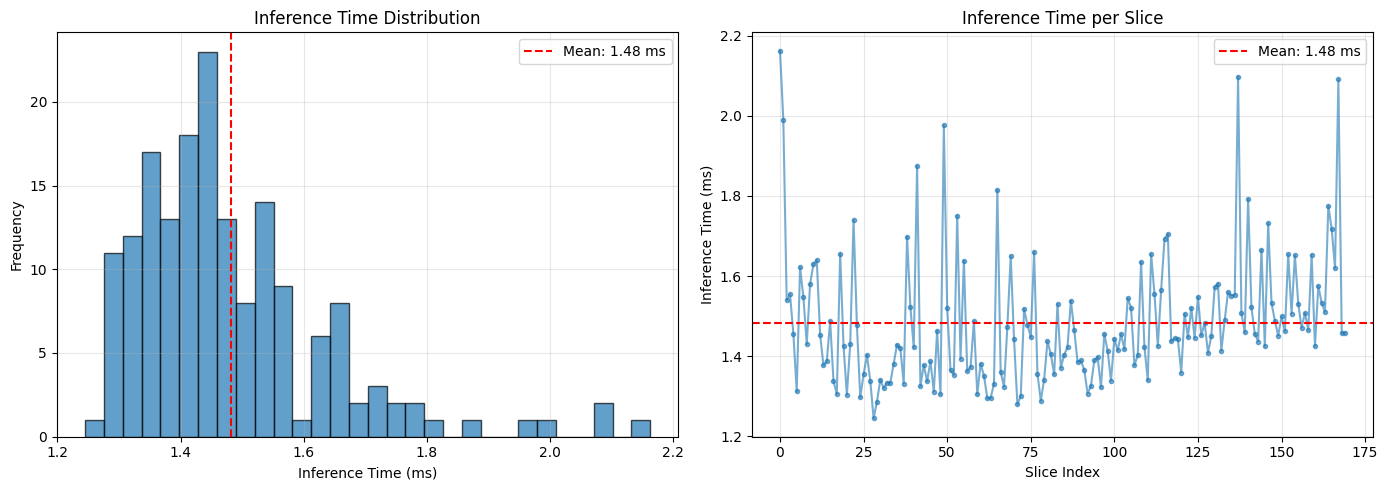

Slices: 170
Mean: 1.48 ms
Std: 0.16 ms
Min: 1.25 ms
Max: 2.16 ms


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.array(inf_times) * 1000, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(inf_times) * 1000, color='red', linestyle='--', label=f'Mean: {np.mean(inf_times)*1000:.2f} ms')
axes[0].set_xlabel('Inference Time (ms)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Inference Time Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(np.array(inf_times) * 1000, marker='o', markersize=3, alpha=0.6)
axes[1].axhline(np.mean(inf_times) * 1000, color='red', linestyle='--', label=f'Mean: {np.mean(inf_times)*1000:.2f} ms')
axes[1].set_xlabel('Slice Index')
axes[1].set_ylabel('Inference Time (ms)')
axes[1].set_title('Inference Time per Slice')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/performance.png', dpi=150)
plt.show()

print(f'Slices: {len(inf_times)}')
print(f'Mean: {np.mean(inf_times)*1000:.2f} ms')
print(f'Std: {np.std(inf_times)*1000:.2f} ms')
print(f'Min: {np.min(inf_times)*1000:.2f} ms')
print(f'Max: {np.max(inf_times)*1000:.2f} ms')


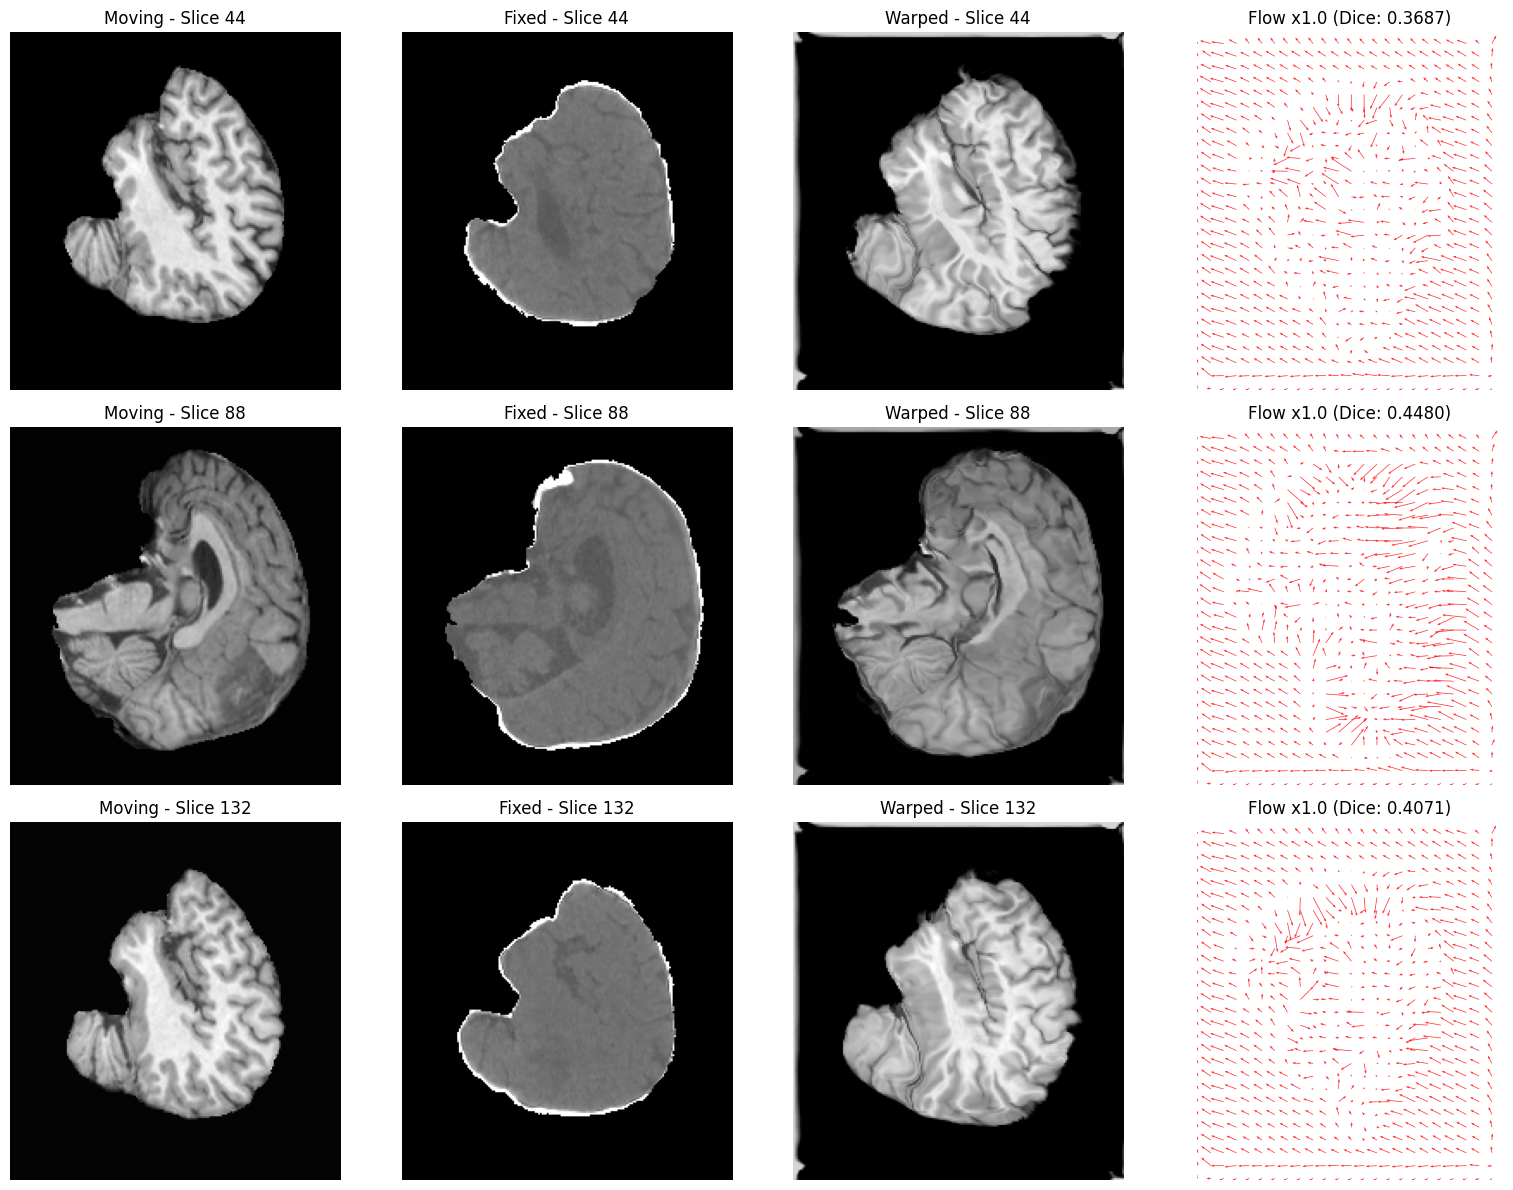

In [9]:
slice_indices = [moving_vol.shape[0]//4, moving_vol.shape[0]//2, 3*moving_vol.shape[0]//4]

fig, axes = plt.subplots(len(slice_indices), 4, figsize=(16, 4*len(slice_indices)))

for i, z in enumerate(slice_indices):
    if WINDOW_RADIUS <= z < moving_vol.shape[0] - WINDOW_RADIUS:
        axes[i, 0].imshow(moving_vol[z], cmap='gray')
        axes[i, 0].set_title(f'Moving - Slice {z}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(fixed_vol[z], cmap='gray')
        axes[i, 1].set_title(f'Fixed - Slice {z}')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(warped_vol[z], cmap='gray')
        axes[i, 2].set_title(f'Warped - Slice {z}')
        axes[i, 2].axis('off')

        if has_seg:
            vol_z_flow = flow_vol[z - WINDOW_RADIUS]
            dice_score = compute_dice(warped_seg_vol[z], fixed_seg[z])
            q_gain, q_p95 = plot_quiver(axes[i, 3], vol_z_flow, step=4, auto_gain=QUIVER_AUTO_GAIN, target_p95=QUIVER_TARGET_P95, max_gain=QUIVER_MAX_GAIN)
            axes[i, 3].set_title(f'Flow x{q_gain:.1f} (Dice: {dice_score:.4f})')
            axes[i, 3].axis('off')
        else:
            diff = np.abs(warped_vol[z] - fixed_vol[z])
            im = axes[i, 3].imshow(diff, cmap='hot')
            axes[i, 3].set_title(f'Diff (MAE: {diff.mean():.4f})')
            axes[i, 3].axis('off')
            plt.colorbar(im, ax=axes[i, 3])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/volume_results.png', dpi=150)
plt.show()


In [10]:
np.save(f'{OUTPUT_DIR}/warped_volume.npy', warped_vol)
np.save(f'{OUTPUT_DIR}/flow_volume.npy', flow_vol)


def _stats(name, arr):
    arr = np.asarray(arr)
    return {
        'name': name,
        'shape': list(arr.shape),
        'min': float(np.min(arr)),
        'max': float(np.max(arr)),
        'mean': float(np.mean(arr)),
        'std': float(np.std(arr)),
    }


def _mi_np(i, j, bins=32):
    i = np.asarray(i, dtype=np.float32)
    j = np.asarray(j, dtype=np.float32)
    i_norm = (i - i.min()) / (i.max() - i.min() + 1e-6)
    j_norm = (j - j.min()) / (j.max() - j.min() + 1e-6)
    i_idx = (i_norm * (bins - 1)).astype(np.int32)
    j_idx = (j_norm * (bins - 1)).astype(np.int32)
    hist, _, _ = np.histogram2d(i_idx.ravel(), j_idx.ravel(), bins=bins, range=[[0, bins - 1], [0, bins - 1]])
    pxy = hist / (np.sum(hist) + 1e-9)
    px = np.sum(pxy, axis=1, keepdims=True)
    py = np.sum(pxy, axis=0, keepdims=True)
    pxpy = px * py
    nz = pxy > 0
    mi = np.sum(pxy[nz] * np.log((pxy[nz] / (pxpy[nz] + 1e-9)) + 1e-9))
    return float(mi)


def _smoothness(flow_chw):
    dy = np.abs(flow_chw[:, 1:, :] - flow_chw[:, :-1, :])
    dx = np.abs(flow_chw[:, :, 1:] - flow_chw[:, :, :-1])
    return float(np.mean(dx * dx) + np.mean(dy * dy))


results = {
    'weights_path': MODEL_PATH,
    'xmodel_path': XMODEL_PATH if Path(XMODEL_PATH).exists() else '',
    'input_hw': [int(INPUT_HEIGHT), int(INPUT_WIDTH)],
    'window_radius': int(WINDOW_RADIUS),
    'n_stack': int(N_STACK),
    'mean_time_ms': float(np.mean(inf_times) * 1000),
    'std_time_ms': float(np.std(inf_times) * 1000),
    'throughput_slices_per_sec': float(len(inf_times) / sum(inf_times)),
    'total_slices': int(len(inf_times)),
    'mi_before': _mi_np(moving_center, fixed_center),
    'mi_after': _mi_np(warped, fixed_center),
    'smoothness': _smoothness(flow),
    'flow': _stats('flow', flow),
    'warped': _stats('warped', warped),
}

if has_seg:
    results['dice_before'] = float(dice_before)
    results['dice_after'] = float(dice_after)

with open(f'{OUTPUT_DIR}/results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'Saved GPU results to {OUTPUT_DIR}')


In [11]:
del model
print('Done')


Done
